# Modelo Multimodal

En este notebook vamos a cargar el modelo entrenado y probarlo con algunas muestras de test. El código descarga automáticamente los pesos y un mini-dataset de prueba (30 muestras) si no están en local.

In [8]:
import os
import sys
import zipfile
import gdown

# Asegurar que estamos en la raíz del proyecto para que funcionen los imports locales
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.append(os.getcwd())

# 1. Descargar pesos si no existen
os.makedirs("models", exist_ok=True)
model_path = "models/multimodal_fusion.pth"

if not os.path.exists(model_path):
    print("Descargando pesos del modelo...")
    gdown.download(id="1a9DWzvJE_ZCFs5s5ZlyDEMQ3vv6MLld7", output=model_path, quiet=False) #id url de la carpeta

# 2. Descargar mini-dataset de prueba
os.makedirs("data/metadata", exist_ok=True)
csv_path = "data/metadata/demo_metadata.csv"
zip_path = "demo_data.zip"

if not os.path.exists(csv_path):
    print("Descargando datos de prueba...")
    gdown.download(id="1AHxUh7FRN9L-cNjmAdvHNT-rZBXlJxK1", output=zip_path, quiet=False) #id url de la carpeta demo zip
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    os.remove(zip_path)
    print("Datos listos.")

In [9]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

from src import config
from src.dataset import RAVDESSMultimodalDataset
from src.models import MultimodalFusion

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cargar modelo
model = MultimodalFusion(num_classes=8).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# Cargar datos
df = pd.read_csv("data/metadata/demo_metadata.csv")
test_ds = RAVDESSMultimodalDataset(df, partition='test')

print(f"Muestras de test cargadas: {len(test_ds)}")

Muestras de test cargadas: 30


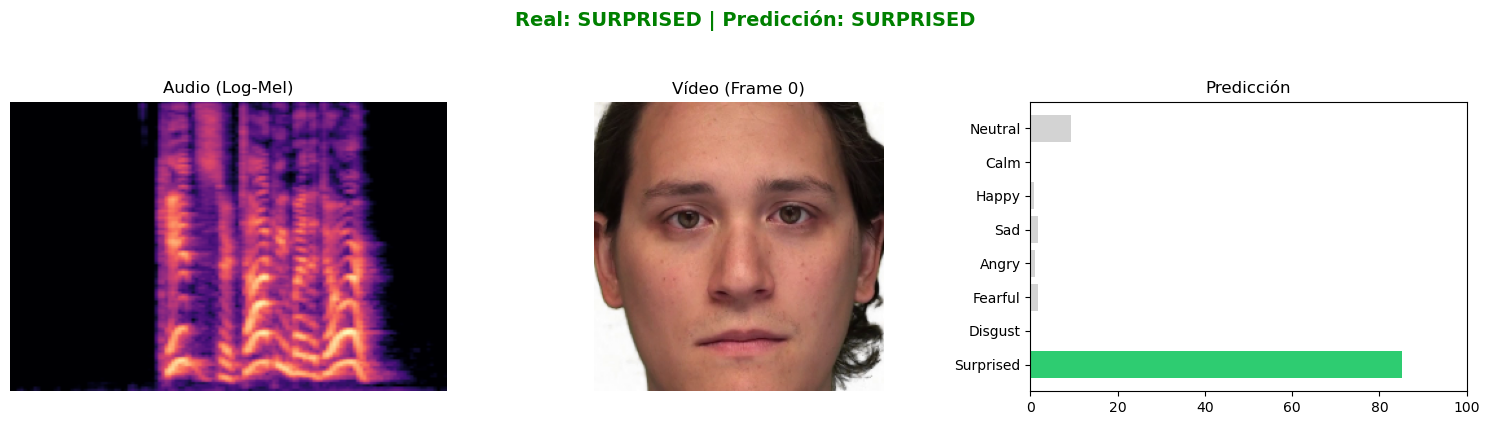

In [12]:
# Coger una muestra al azar
idx = random.randint(0, len(test_ds) - 1)
(audio_tensor, video_tensor), label_tensor = test_ds[idx]

# Añadir dimensión batch
audio_input = audio_tensor.unsqueeze(0).to(device)
video_input = video_tensor.unsqueeze(0).to(device)

# Predecir
with torch.no_grad():
    output = model(audio_input, video_input)
    probs = F.softmax(output, dim=1).squeeze().cpu().numpy() * 100

pred_idx = np.argmax(probs)
true_emotion = config.ID_TO_EMOTION[label_tensor.item()].upper()
pred_emotion = config.ID_TO_EMOTION[pred_idx].upper()

# Pintar resultados
fig = plt.figure(figsize=(15, 4))

# Espectrograma
ax1 = plt.subplot(1, 3, 1)
ax1.imshow(audio_tensor.squeeze().numpy(), origin='lower', aspect='auto', cmap='magma')
ax1.set_title("Audio (Log-Mel)")
ax1.axis('off')

# Frame de vídeo
ax2 = plt.subplot(1, 3, 2)
frame = np.transpose(video_tensor[0].numpy(), (1, 2, 0))
ax2.imshow(np.clip(frame, 0, 1))
ax2.set_title("Vídeo (Frame 0)")
ax2.axis('off')

# Probabilidades
ax3 = plt.subplot(1, 3, 3)
emotions = [config.ID_TO_EMOTION[i].capitalize() for i in range(8)]
colors = ['lightgray' if i != pred_idx else '#2ecc71' for i in range(8)]

y_pos = np.arange(len(emotions))
ax3.barh(y_pos, probs, color=colors)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(emotions)
ax3.invert_yaxis()
ax3.set_xlim(0, 100)
ax3.set_title("Predicción")

color_title = 'green' if true_emotion == pred_emotion else 'red'
fig.suptitle(f"Real: {true_emotion} | Predicción: {pred_emotion}", 
             fontsize=14, fontweight='bold', color=color_title, y=1.05)

plt.tight_layout()
plt.show()